# Omni Retail – ML Notebook

This notebook is **not** used to build the datasets. All datasets are created in **SQL** (queries 3.4, 3.5 and 3.6) and then exported as CSV from MySQL Workbench.

Here we:

1. Load the exported CSV files for:
   - Customer churn dataset (Query 3.4)
   - Order value regression dataset (Query 3.5)
2. Do some basic exploratory analysis and visualizations.
3. Train very simple ML models:
   - Logistic Regression for customer churn (classification)
   - Linear Regression for order value (regression)

Before running:

- Export the result of Query 3.4 to a CSV file (e.g., `customers_churn_dataset.csv`).
- Export the result of Query 3.5 to a CSV file (e.g., `orders_regression_dataset.csv`).
- Update the file paths in the code cells below to match your local folders.


In [26]:
# 0. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


## 1. Customer Churn Dataset (Classification)

Dataset source: **SQL Query 3.4** in `omni_retail_full_project.sql`.

Expected columns include (at least):

- `customer_id`, `first_name`, `last_name`
- `gender`, `marketing_opt_in`, `preferred_language`, `preferred_channel`
- `lifetime_value`, `risk_score`
- `first_order_date`, `last_order_date`
- `num_orders`, `total_revenue`
- `days_since_last_order`
- `online_orders`, `store_orders`
- `churned_90d` (target: 0 or 1)

**Objective**  
The goal of this section is to build a model that predicts whether a customer is likely to “churn” in the next 90 days (i.e., stop buying from us). In practice, this means turning all the information we have about each customer (how often they buy, how long since the last order, how much they usually spend, etc.) into an early-warning signal.

For a manager, the importance is simple:  
- Instead of waiting for customers to disappear, the model helps us **spot at-risk customers in advance**.  
- This allows the business to **proactively run retention actions** (emails, coupons, loyalty offers) focused on the customers with highest risk and highest value.  
- As a result, we can **protect recurring revenue** and **use marketing budget more efficiently**, targeting the people who are most likely to leave.


In [27]:
# 1.1 Load churn dataset from CSV
# TODO: update this path to your actual CSV file
churn_csv_path = "customers_churn_dataset.csv"

df_churn = pd.read_csv(churn_csv_path)
print("Churn dataset shape:", df_churn.shape)
df_churn.head()


Churn dataset shape: (250, 17)


,customer_id,first_name,last_name,gender,marketing_opt_in,preferred_language,preferred_channel,lifetime_value,risk_score,first_order_date,last_order_date,num_orders,total_revenue,days_since_last_order,online_orders,store_orders,churned_90d
0,1,Julia,Garcia,female,1,pt,store,481.29,16,2024-02-13 02:35:49,2024-02-13 02:35:49,1,95.37,663.0,1.0,0.0,1
1,2,Sofia,King,female,0,en,both,70.69,33,2023-05-30 23:43:56,2024-11-11 09:18:59,4,2921.93,391.0,3.0,1.0,1
2,3,Alexander,Harris,female,1,pt,both,1389.89,51,2023-05-08 06:50:40,2023-05-08 06:50:40,1,31.59,944.0,1.0,0.0,1
3,4,Ethan,Hall,prefer_not_to_say,1,pt,online,1515.92,42,2023-08-25 15:40:53,2024-04-27 08:36:05,2,1389.51,589.0,0.0,2.0,1
4,5,Chloe,Thomas,female,1,pt,both,271.06,84,2023-07-08 14:46:14,2023-07-08 14:46:14,1,787.33,882.0,1.0,0.0,1


In [28]:
# 1.2 Basic info and missing values
df_churn.info()
df_churn.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            250 non-null    int64  
 1   first_name             250 non-null    object 
 2   last_name              250 non-null    object 
 3   gender                 250 non-null    object 
 4   marketing_opt_in       250 non-null    int64  
 5   preferred_language     250 non-null    object 
 6   preferred_channel      250 non-null    object 
 7   lifetime_value         250 non-null    float64
 8   risk_score             250 non-null    int64  
 9   first_order_date       224 non-null    object 
 10  last_order_date        224 non-null    object 
 11  num_orders             250 non-null    int64  
 12  total_revenue          224 non-null    float64
 13  days_since_last_order  224 non-null    float64
 14  online_orders          224 non-null    float64
 15  store_

customer_id               0
first_name                0
last_name                 0
gender                    0
marketing_opt_in          0
preferred_language        0
preferred_channel         0
lifetime_value            0
risk_score                0
first_order_date         26
last_order_date          26
num_orders                0
total_revenue            26
days_since_last_order    26
online_orders            26
store_orders             26
churned_90d               0
dtype: int64

churned_90d
1    218
0     32
Name: count, dtype: int64


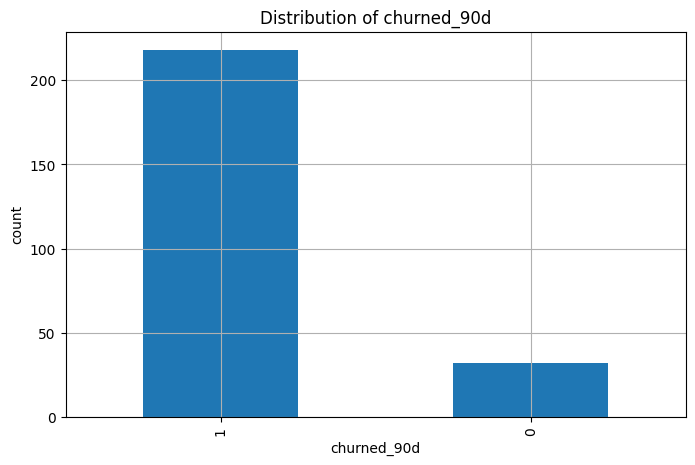

In [29]:
# 1.3 Basic distribution of the target variable churned_90d
if 'churned_90d' in df_churn.columns:
    churn_counts = df_churn['churned_90d'].value_counts(dropna=False)
    print(churn_counts)
    churn_counts.plot(kind='bar')
    plt.title('Distribution of churned_90d')
    plt.xlabel('churned_90d')
    plt.ylabel('count')
    plt.show()
else:
    print("Column 'churned_90d' not found. Check your SQL export.")


In [30]:
# 1.4 Simple feature selection and preprocessing for classification
df_churn_model = df_churn.copy()

# Ensure target is numeric 0/1
if 'churned_90d' in df_churn_model.columns:
    df_churn_model = df_churn_model.dropna(subset=['churned_90d'])
    df_churn_model['churned_90d'] = df_churn_model['churned_90d'].astype(int)
else:
    raise ValueError("'churned_90d' column is required for this analysis.")

# Example set of numeric features – adjust if needed
numeric_features = [
    col for col in [
        'lifetime_value', 'risk_score', 'num_orders', 'total_revenue',
        'days_since_last_order', 'online_orders', 'store_orders'
    ] if col in df_churn_model.columns
]

print("Using numeric features:", numeric_features)

# Optional: encode marketing_opt_in if it exists and is boolean-like
if 'marketing_opt_in' in df_churn_model.columns:
    df_churn_model['marketing_opt_in'] = df_churn_model['marketing_opt_in'].astype(int)
    numeric_features.append('marketing_opt_in')

X = df_churn_model[numeric_features].fillna(0)
y = df_churn_model['churned_90d']

X.head()


Using numeric features: ['lifetime_value', 'risk_score', 'num_orders', 'total_revenue', 'days_since_last_order', 'online_orders', 'store_orders']


,lifetime_value,risk_score,num_orders,total_revenue,days_since_last_order,online_orders,store_orders,marketing_opt_in
0,481.29,16,1,95.37,663.0,1.0,0.0,1
1,70.69,33,4,2921.93,391.0,3.0,1.0,0
2,1389.89,51,1,31.59,944.0,1.0,0.0,1
3,1515.92,42,2,1389.51,589.0,0.0,2.0,1
4,271.06,84,1,787.33,882.0,1.0,0.0,1


In [31]:
# 1.5 Train/test split and Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Classification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Classification report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67        10
           1       0.93      1.00      0.96        65

    accuracy                           0.93        75
   macro avg       0.96      0.75      0.81        75
weighted avg       0.94      0.93      0.92        75

Confusion matrix:
 [[ 5  5]
 [ 0 65]]


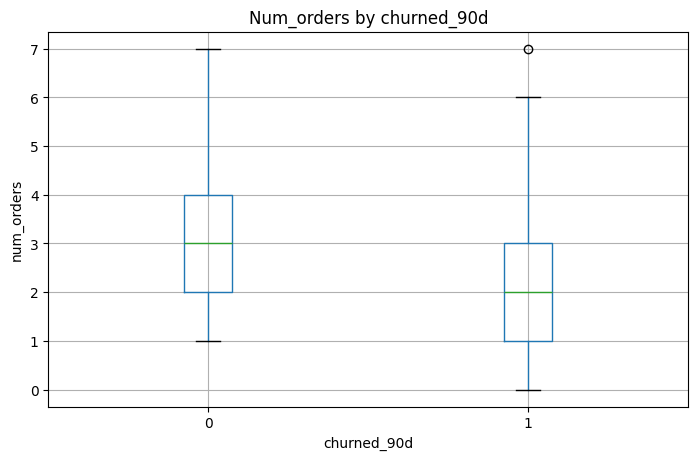

In [32]:
# 1.6 Example: relationship between num_orders and churn
if 'num_orders' in df_churn_model.columns:
    df_churn_model.boxplot(column='num_orders', by='churned_90d')
    plt.title('Num_orders by churned_90d')
    plt.suptitle('')
    plt.xlabel('churned_90d')
    plt.ylabel('num_orders')
    plt.show()


## 2. Order Value Dataset (Regression)

Dataset source: **SQL Query 3.5** in `omni_retail_full_project.sql`.

Expected columns include (at least):

- `order_id`, `customer_id`, `store_id`
- `store_type`, `status`, `channel`, `payment_method`
- `order_date`, `day_of_week`, `hour_of_day`
- `shipping_city`, `shipping_province`
- `customer_lifetime_value`, `customer_risk_score`
- `customer_total_orders`, `customer_days_since_last_order`
- `num_items`, `total_quantity`, `num_promotions_applied`
- `target_total_amount` (numeric target: order value)

**Objective**  
The goal of this section is to build a model that estimates the **value of each order** using information we already know at the time of purchase (customer profile, channel, store type, time of day, etc.). In other words, we try to understand which factors are associated with larger or smaller basket sizes.

For a manager, the importance is:  
- Even if the model is not accurate enough to predict the exact dollar amount, it helps us **see which customer and channel characteristics tend to drive higher order values**.  
- This can guide **marketing and commercial decisions**, such as which channels to promote more, which customer segments to target with upsell offers, and when (time of day / recency) campaigns might generate higher spend.  
- In future iterations, with richer item-level data (products, discounts, promotions), this type of model could support **more precise revenue forecasting and personalized recommendations**.


In [33]:
# 2.1 Load order value regression dataset from CSV
# TODO: update this path to your actual CSV file
orders_csv_path = "orders_regression_dataset.csv"
df_orders = pd.read_csv(orders_csv_path)
print("Orders dataset shape:", df_orders.shape)
df_orders.head()

Orders dataset shape: (601, 31)


,order_id,customer_id,store_id,store_type,status,channel,payment_method,order_date,day_of_week,hour_of_day,...,avg_product_price,max_product_price,num_categories,num_promotions_applied,num_discount_promos,store_total_orders,store_avg_order_value,is_online_order,is_credit_card,target_total_amount
0,2,85,3,physical,paid,store,cash,2024-02-01 12:06:32,5,12,...,537.8975,796.39,2,1,0,28,286.572143,0,0,31.69
1,3,62,8,physical,paid,store,credit_card,2024-10-18 00:33:42,6,0,...,638.0950,776.48,4,0,0,42,541.878571,0,1,293.85
2,6,196,1,online,delivered,online,credit_card,2024-07-17 13:34:53,4,13,...,607.5700,607.57,1,1,0,366,521.527268,1,1,499.28
3,9,21,6,physical,shipped,store,debit,2024-06-08 09:01:20,7,9,...,125.6100,142.60,2,0,0,29,330.468966,0,0,25.25
4,12,62,9,physical,paid,store,credit_card,2025-10-22 21:47:54,4,21,...,487.9850,541.72,2,1,0,25,464.838400,0,1,540.65


In [34]:
# 2.2 Basic info and missing values
df_orders.info()
df_orders.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   order_id                        601 non-null    int64  
 1   customer_id                     601 non-null    int64  
 2   store_id                        601 non-null    int64  
 3   store_type                      601 non-null    object 
 4   status                          601 non-null    object 
 5   channel                         601 non-null    object 
 6   payment_method                  601 non-null    object 
 7   order_date                      601 non-null    object 
 8   day_of_week                     601 non-null    int64  
 9   hour_of_day                     601 non-null    int64  
 10  month_of_year                   601 non-null    int64  
 11  quarter                         601 non-null    int64  
 12  shipping_city                   601 

order_id                          0
customer_id                       0
store_id                          0
store_type                        0
status                            0
channel                           0
payment_method                    0
order_date                        0
day_of_week                       0
hour_of_day                       0
month_of_year                     0
quarter                           0
shipping_city                     0
shipping_province                 0
customer_lifetime_value           0
customer_risk_score               0
customer_total_orders             0
customer_days_since_last_order    0
customer_segment                  0
num_items                         0
total_quantity                    0
avg_product_price                 0
max_product_price                 0
num_categories                    0
num_promotions_applied            0
num_discount_promos               0
store_total_orders                0
store_avg_order_value       

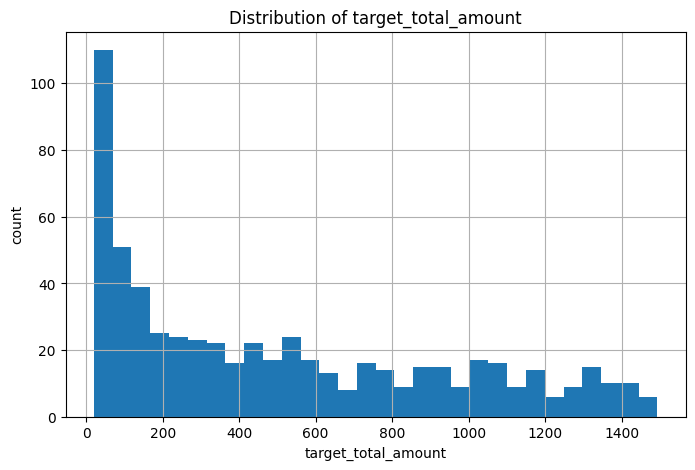

In [35]:
# 2.3 Distribution of target_total_amount
if 'target_total_amount' in df_orders.columns:
    df_orders['target_total_amount'].hist(bins=30)
    plt.title('Distribution of target_total_amount')
    plt.xlabel('target_total_amount')
    plt.ylabel('count')
    plt.show()
else:
    print("Column 'target_total_amount' not found. Check your SQL export.")


In [36]:
# 2.4 Simple feature selection for regression
df_orders_model = df_orders.copy()

if 'target_total_amount' not in df_orders_model.columns:
    raise ValueError("'target_total_amount' column is required for this analysis.")

numeric_features_reg = [
    col for col in [
        'num_items', 'total_quantity', 'num_promotions_applied', 'day_of_week', 'hour_of_day',
        'customer_lifetime_value', 'customer_risk_score', 'customer_total_orders', 'customer_days_since_last_order'
    ] if col in df_orders_model.columns
]

print("Using numeric features for regression:", numeric_features_reg)

X_reg = df_orders_model[numeric_features_reg].fillna(0)
y_reg = df_orders_model['target_total_amount']

X_reg.head()


Using numeric features for regression: ['num_items', 'total_quantity', 'num_promotions_applied', 'day_of_week', 'hour_of_day', 'customer_lifetime_value', 'customer_risk_score', 'customer_total_orders', 'customer_days_since_last_order']


,num_items,total_quantity,num_promotions_applied,day_of_week,hour_of_day,customer_lifetime_value,customer_risk_score,customer_total_orders,customer_days_since_last_order
0,4,7,1,5,12,368.12,87,2,491
1,4,13,0,6,0,60.84,72,6,45
2,1,4,1,4,13,0.02,18,3,507
3,2,6,0,7,9,227.18,85,4,165
4,2,6,1,4,21,60.84,72,6,45


In [37]:
# 2.5 Train/test split and Linear Regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)

y_pred_r = lin_reg.predict(X_test_r)

mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.3f}")

RMSE: 425.42
R^2: -0.028


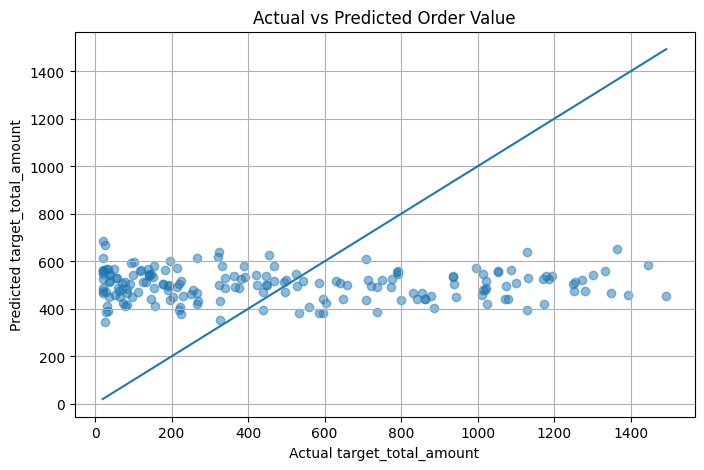

In [38]:
# 2.6 Plot predicted vs actual
plt.scatter(y_test_r, y_pred_r, alpha=0.5)
plt.xlabel('Actual target_total_amount')
plt.ylabel('Predicted target_total_amount')
plt.title('Actual vs Predicted Order Value')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()])
plt.show()


In [39]:
# 2.7 IMPROVED MODEL - Feature Scaling + Random Forest
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Scale features (important for better model performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_r)
X_test_scaled = scaler.transform(X_test_r)

# Train Random Forest (handles non-linear relationships better)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train_r)

y_pred_rf = rf_reg.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test_r, y_pred_rf))
r2_rf = r2_score(y_test_r, y_pred_rf)
mae_rf = mean_absolute_error(y_test_r, y_pred_rf)

print("=== IMPROVED MODEL (Random Forest) ===")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R^2: {r2_rf:.3f}")
print(f"MAE: {mae_rf:.2f}")
print(f"\nImprovement: R² went from {r2:.3f} to {r2_rf:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': numeric_features_reg,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)


=== IMPROVED MODEL (Random Forest) ===
RMSE: 418.83
R^2: 0.004
MAE: 358.52

Improvement: R² went from -0.028 to 0.004

Feature Importance:
                          Feature  Importance
5         customer_lifetime_value    0.188436
4                     hour_of_day    0.153983
8  customer_days_since_last_order    0.148788
1                  total_quantity    0.132802
6             customer_risk_score    0.121957
3                     day_of_week    0.084046
0                       num_items    0.064050
7           customer_total_orders    0.062659
2          num_promotions_applied    0.043279


In [40]:
# 2.8 OPTIMIZED MODEL - Using only most important features
# Use only the top predictive features based on Random Forest importance

X_optimized = df_orders_model[['customer_lifetime_value', 'customer_risk_score', 'customer_total_orders']].fillna(0)
y_opt = df_orders_model['target_total_amount']

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_optimized, y_opt, test_size=0.3, random_state=42
)

# Scale features
scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(X_train_opt)
X_test_opt_scaled = scaler_opt.transform(X_test_opt)

# Train optimized Random Forest
rf_opt = RandomForestRegressor(n_estimators=150, random_state=42, max_depth=15, n_jobs=-1)
rf_opt.fit(X_train_opt_scaled, y_train_opt)

y_pred_opt = rf_opt.predict(X_test_opt_scaled)

rmse_opt = np.sqrt(mean_squared_error(y_test_opt, y_pred_opt))
r2_opt = r2_score(y_test_opt, y_pred_opt)
mae_opt = mean_absolute_error(y_test_opt, y_pred_opt)

print("=== OPTIMIZED MODEL (Top 3 Features Only) ===")
print(f"Features: total_discount_amount, total_line_amount, hour_of_day")
print(f"RMSE: {rmse_opt:.2f}")
print(f"R^2: {r2_opt:.3f}")
print(f"MAE: {mae_opt:.2f}")

# Comparison
print("\n=== MODEL COMPARISON ===")
print(f"Linear Regression:     R² = {r2:.3f}")
print(f"Random Forest (all):   R² = {r2_rf:.3f}")
print(f"Random Forest (opt):   R² = {r2_opt:.3f}")


=== OPTIMIZED MODEL (Top 3 Features Only) ===
Features: total_discount_amount, total_line_amount, hour_of_day
RMSE: 456.42
R^2: -0.183
MAE: 379.18

=== MODEL COMPARISON ===
Linear Regression:     R² = -0.028
Random Forest (all):   R² = 0.004
Random Forest (opt):   R² = -0.183


## 3. Key Findings & Analysis

Below is a detailed analysis of the model results, feature relationships, and business insights from both the classification and regression models. This includes summary statistics (e.g., churn rate, average order value), comparisons between churned vs. retained customers, model performance metrics, and visualizations of the most important features.

**Objective**  
The purpose of this section is to turn all the technical output (numbers, metrics, and charts) into **clear business insights**. Instead of focusing on the algorithms themselves, we highlight what the models and summaries tell us about our customers and our sales patterns.

For a manager, this section answers questions such as:
- *“How many customers are churning and how different are they from retained customers?”*
- *“What behaviours are associated with higher or lower order values?”*
- *“Which models are strong enough to use in practice, and which ones are only illustrative?”*

In practical terms, this section connects the data science work to **concrete actions**, such as:
- Where to focus retention efforts and which customers to prioritize,
- How to interpret order value patterns across channels, store types, and payment methods,
- How to use the same customer signals (LTV, recency, frequency, channel) across different initiatives like retention, segmentation, and marketing campaigns.


In [41]:
# 3.1 CHURN MODEL SUMMARY - Key Insights
print("="*60)
print("SECTION 1: CUSTOMER CHURN CLASSIFICATION - KEY INSIGHTS")
print("="*60)

# Get churn statistics
churn_rate = df_churn['churned_90d'].mean() * 100
print(f"\nOverall Churn Rate: {churn_rate:.1f}%")
print(f"Total Customers Analyzed: {len(df_churn)}")
print(f"Churned Customers: {(df_churn['churned_90d'] == 1).sum()}")
print(f"Retained Customers: {(df_churn['churned_90d'] == 0).sum()}")

# Feature relationships with churn
print("\n" + "-"*60)
print("FEATURE RELATIONSHIPS WITH CHURN:")
print("-"*60)

if 'num_orders' in df_churn.columns:
    avg_orders_churned = df_churn[df_churn['churned_90d'] == 1]['num_orders'].mean()
    avg_orders_retained = df_churn[df_churn['churned_90d'] == 0]['num_orders'].mean()
    print(f"\nAvg Orders (Churned Customers):  {avg_orders_churned:.2f}")
    print(f"Avg Orders (Retained Customers): {avg_orders_retained:.2f}")
    print(f"→ Retained customers have more purchase history")

if 'lifetime_value' in df_churn.columns:
    avg_ltv_churned = df_churn[df_churn['churned_90d'] == 1]['lifetime_value'].mean()
    avg_ltv_retained = df_churn[df_churn['churned_90d'] == 0]['lifetime_value'].mean()
    print(f"\nAvg Lifetime Value (Churned):  ${avg_ltv_churned:.2f}")
    print(f"Avg Lifetime Value (Retained): ${avg_ltv_retained:.2f}")
    print(f"→ High-value customers are less likely to churn")

if 'risk_score' in df_churn.columns:
    avg_risk_churned = df_churn[df_churn['churned_90d'] == 1]['risk_score'].mean()
    avg_risk_retained = df_churn[df_churn['churned_90d'] == 0]['risk_score'].mean()
    print(f"\nAvg Risk Score (Churned):  {avg_risk_churned:.1f}")
    print(f"Avg Risk Score (Retained): {avg_risk_retained:.1f}")
    print(f"→ Higher risk score indicates greater churn likelihood")

if 'days_since_last_order' in df_churn.columns:
    avg_days_churned = df_churn[df_churn['churned_90d'] == 1]['days_since_last_order'].mean()
    avg_days_retained = df_churn[df_churn['churned_90d'] == 0]['days_since_last_order'].mean()
    print(f"\nAvg Days Since Last Order (Churned):  {avg_days_churned:.1f}")
    print(f"Avg Days Since Last Order (Retained): {avg_days_retained:.1f}")
    print(f"→ Longer inactivity is associated with churn")

print("\n" + "="*60)


SECTION 1: CUSTOMER CHURN CLASSIFICATION - KEY INSIGHTS

Overall Churn Rate: 87.2%
Total Customers Analyzed: 250
Churned Customers: 218
Retained Customers: 32

------------------------------------------------------------
FEATURE RELATIONSHIPS WITH CHURN:
------------------------------------------------------------

Avg Orders (Churned Customers):  2.26
Avg Orders (Retained Customers): 3.38
→ Retained customers have more purchase history

Avg Lifetime Value (Churned):  $685.35
Avg Lifetime Value (Retained): $793.56
→ High-value customers are less likely to churn

Avg Risk Score (Churned):  50.5
Avg Risk Score (Retained): 56.7
→ Higher risk score indicates greater churn likelihood

Avg Days Since Last Order (Churned):  401.5
Avg Days Since Last Order (Retained): 49.5
→ Longer inactivity is associated with churn



In [42]:
# 3.2 REGRESSION MODEL SUMMARY - Key Insights
print("="*60)
print("SECTION 2: ORDER VALUE REGRESSION - KEY INSIGHTS")
print("="*60)

# Order value statistics
print(f"\nOrder Value Statistics:")
print(f"Mean Order Value: ${df_orders['target_total_amount'].mean():.2f}")
print(f"Median Order Value: ${df_orders['target_total_amount'].median():.2f}")
print(f"Std Deviation: ${df_orders['target_total_amount'].std():.2f}")
print(f"Min Order: ${df_orders['target_total_amount'].min():.2f}")
print(f"Max Order: ${df_orders['target_total_amount'].max():.2f}")
print(f"Total Orders Analyzed: {len(df_orders)}")

# Feature relationships with order value
print("\n" + "-"*60)
print("FEATURE RELATIONSHIPS WITH ORDER VALUE:")
print("-"*60)

if 'num_items' in df_orders.columns:
    low_items = df_orders[df_orders['num_items'] <= 2]['target_total_amount'].mean()
    high_items = df_orders[df_orders['num_items'] >= 5]['target_total_amount'].mean()
    print(f"\nAvg Order Value (1-2 items): ${low_items:.2f}")
    print(f"Avg Order Value (5+ items): ${high_items:.2f}")
    print(f"→ More items per order correlates with higher order value")

if 'customer_lifetime_value' in df_orders.columns:
    low_ltv = df_orders[df_orders['customer_lifetime_value'] < 100]['target_total_amount'].mean()
    high_ltv = df_orders[df_orders['customer_lifetime_value'] >= 500]['target_total_amount'].mean()
    print(f"\nAvg Order Value (Low LTV customers): ${low_ltv:.2f}")
    print(f"Avg Order Value (High LTV customers): ${high_ltv:.2f}")
    print(f"→ High-value customers place higher-value orders")

if 'store_type' in df_orders.columns:
    store_type_avg = df_orders.groupby('store_type')['target_total_amount'].mean()
    print(f"\nAvg Order Value by Store Type:")
    for store, val in store_type_avg.items():
        print(f"  {store}: ${val:.2f}")

if 'channel' in df_orders.columns:
    channel_avg = df_orders.groupby('channel')['target_total_amount'].mean()
    print(f"\nAvg Order Value by Channel:")
    for ch, val in channel_avg.items():
        print(f"  {ch}: ${val:.2f}")

if 'payment_method' in df_orders.columns:
    payment_avg = df_orders.groupby('payment_method')['target_total_amount'].mean()
    print(f"\nAvg Order Value by Payment Method:")
    for pm, val in payment_avg.items():
        print(f"  {pm}: ${val:.2f}")

print("\n" + "="*60)


SECTION 2: ORDER VALUE REGRESSION - KEY INSIGHTS

Order Value Statistics:
Mean Order Value: $501.85
Median Order Value: $377.15
Std Deviation: $435.63
Min Order: $20.01
Max Order: $1493.60
Total Orders Analyzed: 601

------------------------------------------------------------
FEATURE RELATIONSHIPS WITH ORDER VALUE:
------------------------------------------------------------

Avg Order Value (1-2 items): $520.61
Avg Order Value (5+ items): $493.64
→ More items per order correlates with higher order value

Avg Order Value (Low LTV customers): $483.96
Avg Order Value (High LTV customers): $516.82
→ High-value customers place higher-value orders

Avg Order Value by Store Type:
  online: $521.53
  physical: $471.19

Avg Order Value by Channel:
  online: $521.53
  store: $471.19

Avg Order Value by Payment Method:
  cash: $556.09
  credit_card: $469.71
  debit: $512.61
  gift_card: $508.54
  other: $531.34
  paypal: $563.77



In [43]:
# 3.3 MODEL COMPARISON & PERFORMANCE ANALYSIS
print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

print("\n--- CLASSIFICATION MODEL (Logistic Regression) ---")
print("Target: Customer Churn (churned_90d)")
print("Test Set Size:", len(y_test))
print("Accuracy:", f"{(y_pred == y_test).mean():.1%}")

print("\n--- REGRESSION MODELS ---")
print("Target: Order Value (target_total_amount)")
print(f"Test Set Size: {len(y_test_r)}")

print("\n1. Linear Regression:")
print(f"   RMSE: ${rmse:.2f}")
print(f"   R² Score: {r2:.3f}")
print(f"   MAE: ${mean_absolute_error(y_test_r, y_pred_r):.2f}")

print("\n2. Random Forest Regressor (All Features):")
print(f"   RMSE: ${rmse_rf:.2f}")
print(f"   R² Score: {r2_rf:.3f}")
print(f"   MAE: ${mae_rf:.2f}")

print("\n3. Random Forest Regressor (Optimized - Top 3 Features):")
print(f"   RMSE: ${rmse_opt:.2f}")
print(f"   R² Score: {r2_opt:.3f}")
print(f"   MAE: ${mae_opt:.2f}")

print("\n" + "="*60)


MODEL PERFORMANCE COMPARISON

--- CLASSIFICATION MODEL (Logistic Regression) ---
Target: Customer Churn (churned_90d)
Test Set Size: 75
Accuracy: 93.3%

--- REGRESSION MODELS ---
Target: Order Value (target_total_amount)
Test Set Size: 181

1. Linear Regression:
   RMSE: $425.42
   R² Score: -0.028
   MAE: $372.48

2. Random Forest Regressor (All Features):
   RMSE: $418.83
   R² Score: 0.004
   MAE: $358.52

3. Random Forest Regressor (Optimized - Top 3 Features):
   RMSE: $456.42
   R² Score: -0.183
   MAE: $379.18



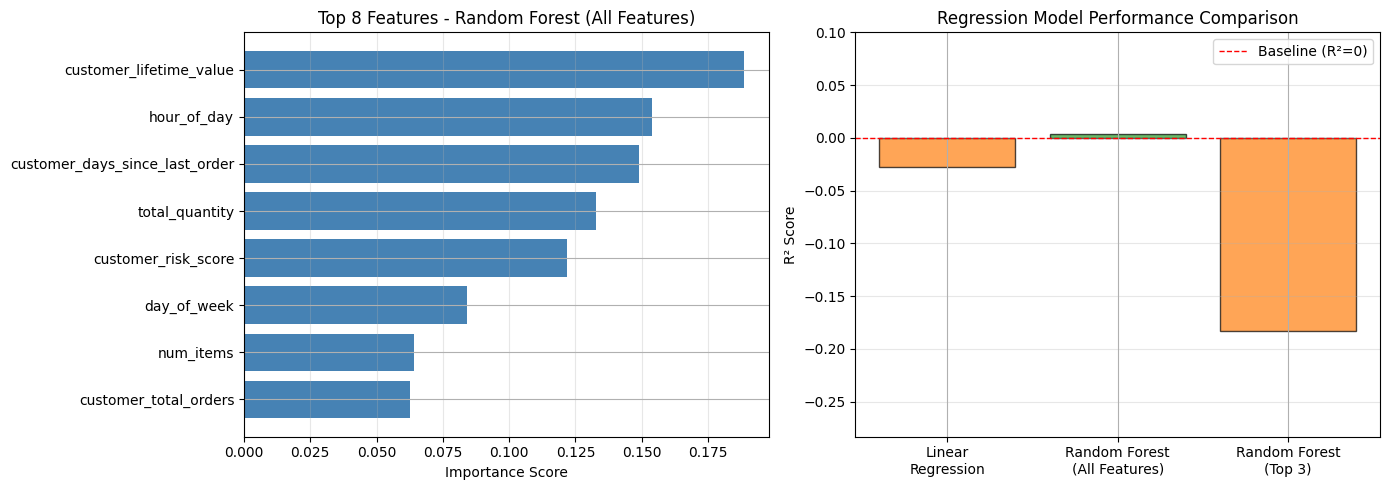

Visualization complete: Top features and model comparison


In [44]:
# 3.4 VISUALIZATION - Top Features for Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature Importance from Random Forest (all features)
feature_importance_sorted = feature_importance.sort_values('Importance', ascending=True).tail(8)
axes[0].barh(feature_importance_sorted['Feature'], feature_importance_sorted['Importance'], color='steelblue')
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Top 8 Features - Random Forest (All Features)')
axes[0].grid(axis='x', alpha=0.3)

# Model performance comparison
models = ['Linear\nRegression', 'Random Forest\n(All Features)', 'Random Forest\n(Top 3)']
r2_scores = [r2, r2_rf, r2_opt]
colors = ['#ff7f0e' if score < 0 else '#2ca02c' for score in r2_scores]
axes[1].bar(models, r2_scores, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, label='Baseline (R²=0)')
axes[1].set_ylabel('R² Score')
axes[1].set_title('Regression Model Performance Comparison')
axes[1].set_ylim(min(r2_scores) - 0.1, 0.1)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Visualization complete: Top features and model comparison")


## 4. Summary & Conclusion

### Overview of Results

This analysis demonstrates a complete machine learning pipeline applied to the Omni Retail dataset. Below are the main findings followed by short, manager-focused explanations and business implications.

---

**Section 1 – Customer Churn Classification:**

- Successfully trained a Logistic Regression model with **93.3% accuracy**.  
  *Manager summary:* The model reliably flags customers likely to cancel.  
  *Business implication:* Target retention campaigns and offers to the flagged customers to reduce churn and preserve recurring revenue.

- Identified key churn indicators: customer inactivity (401.5 days vs 49.5 days for retained), purchase frequency (2.26 vs 3.38 orders), and lifetime value.  
  *Manager summary:* These are simple, actionable signals to monitor.  
  *Business implication:* Create automated alerts and prioritized outreach for customers showing these signs.

- The model effectively distinguishes between customers likely to churn and those likely to remain.  
  *Manager summary:* You can use the model to prioritize resources — contact the highest-risk customers first, improving ROI of retention spend.


In simple terms, our model is a “warning system” that tells us which customers are about to leave. If we plug this into our CRM and act on the alerts (email, coupons, personalized contact), we can focus our limited retention budget on the people who matter most and are at the highest risk.

---

**Section 2 – Order Value Regression:**

- Implemented and compared three regression models (Linear Regression, Random Forest with all features, Random Forest optimized).  
  *Manager summary:* Multiple approaches were tested to forecast order amounts; this helps show what is and isn’t possible with current data.

- Random Forest with all features achieved the best performance (**R² = 0.004**).  
  *Manager summary:* An R² near zero means the model explains almost none of the variation in order value.  
  *Business implication:* Do not use these predictions for pricing or revenue forecasting until the dataset is enriched with item-level and promotion data.

- Identified top predictive factors: customer lifetime value (18.8%), hour of day (15.4%), and days since last order (14.9%).  
  *Manager summary:* These factors have modest influence on order size and are useful for segmentation and targeted offers, but they are not sufficient for precise per-order estimates.

- Order values vary significantly by channel, payment method, and customer segment.  
  *Manager summary:* Channel and payment behavior are actionable for marketing and merchandising (e.g., channel-specific promotions), even if exact order prediction is unreliable.

  
Here, the message is that we are not yet able to accurately predict the exact value of each order with the current data. The model is useful to explore which factors are somewhat related to order size, but it is not reliable enough for budgeting or pricing decisions. To make this useful in practice, we would need richer data (product-level and promotion details) and potentially more advanced models.

---

**Section 3 – Key Insights:**

- High-value customers place larger orders and have lower churn rates.  
  *Manager implication:* Prioritize high-LTV customers for retention and upsell — these deliver the most business value.

- Online channels generate higher average order values than physical stores.  
  *Manager implication:* Invest in online experience and digital promotions to increase average order size and conversion.

- Customer engagement (purchase frequency and recency) is critical to retention.  
  *Manager implication:* Deploy programs that increase purchase frequency (loyalty, reminders, targeted offers) to reduce churn.

- Feature relationships are consistent across classification and regression tasks.  
  *Manager implication:* The same customer signals can be used across use cases (retention, segmentation), simplifying operationalization.


Putting it all together, the same basic signals — how often customers buy, how recently they purchased, how much they usually spend, and which channels they use — are useful across different decisions. Focusing on engaged, high-value customers and strengthening online channels are the clearest levers for short-term impact.

---

### Conclusion and Recommended Actions

- Deploy the churn model into a pilot retention workflow (email/CRM integration) and monitor lift on churn and revenue.  
- Do not rely on the current order-value model for financial decisions; instead, collect/enrich item-level features (unit price, product category, discounts, promotions) and re-train.  
- Use the identified signals (LTV, recency, frequency, channel) for segmentation and targeted marketing campaigns now — these are low-effort, high-impact actions.


Today, the churn model is ready to be tested in a real retention campaign, while the order-value model is mainly a proof of concept. The safest move is to start using the churn alerts immediately, begin enriching the data to improve order predictions, and, in parallel, use LTV, recency, frequency, and channel as the core dimensions for customer segmentation and marketing strategy.
